In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
def print_tree(startpath, max_depth=3):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        if level > max_depth:
            continue
        indent = ' ' * 4 * (level)
        print(f'{indent}|-- {os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for i, f in enumerate(files):
            if i < 5:
                print(f'{subindent}|-- {f}')
            elif i == 5:
                print(f'{subindent}|-- ... ({len(files)} total files)')
                break

dataset_path = '/kaggle/input/datasets/khlaifiabilel/pastis'
print_tree(dataset_path)

|-- pastis/
    |-- PASTIS/
        |-- metadata.geojson
        |-- NORM_S2_patch.json
        |-- DATA_S2/
            |-- S2_40526.npy
            |-- S2_40374.npy
            |-- S2_30078.npy
            |-- S2_20493.npy
            |-- S2_20160.npy
            |-- ... (2468 total files)
        |-- ANNOTATIONS/
            |-- TARGET_20181.npy
            |-- TARGET_40211.npy
            |-- TARGET_30056.npy
            |-- ParcelIDs_20654.npy
            |-- ParcelIDs_20135.npy
            |-- ... (4866 total files)
        |-- INSTANCE_ANNOTATIONS/
            |-- INSTANCES_20420.npy
            |-- HEATMAP_10220.npy
            |-- ZONES_20472.npy
            |-- INSTANCES_30696.npy
            |-- INSTANCES_10002.npy
            |-- ... (7299 total files)


--------------------------------------------------
ЭНТОМОЛОГИЯ ТЕНЗОРА (Анализ структуры):
Файл данных: S2_40526.npy
Shape данных: (38, 10, 128, 128) -> (Время: 38, Каналы: 10, Размер: 128x128)
Shape маски:  (128, 128) -> (Уникальных классов на снимке: [ 0  1 19])
--------------------------------------------------


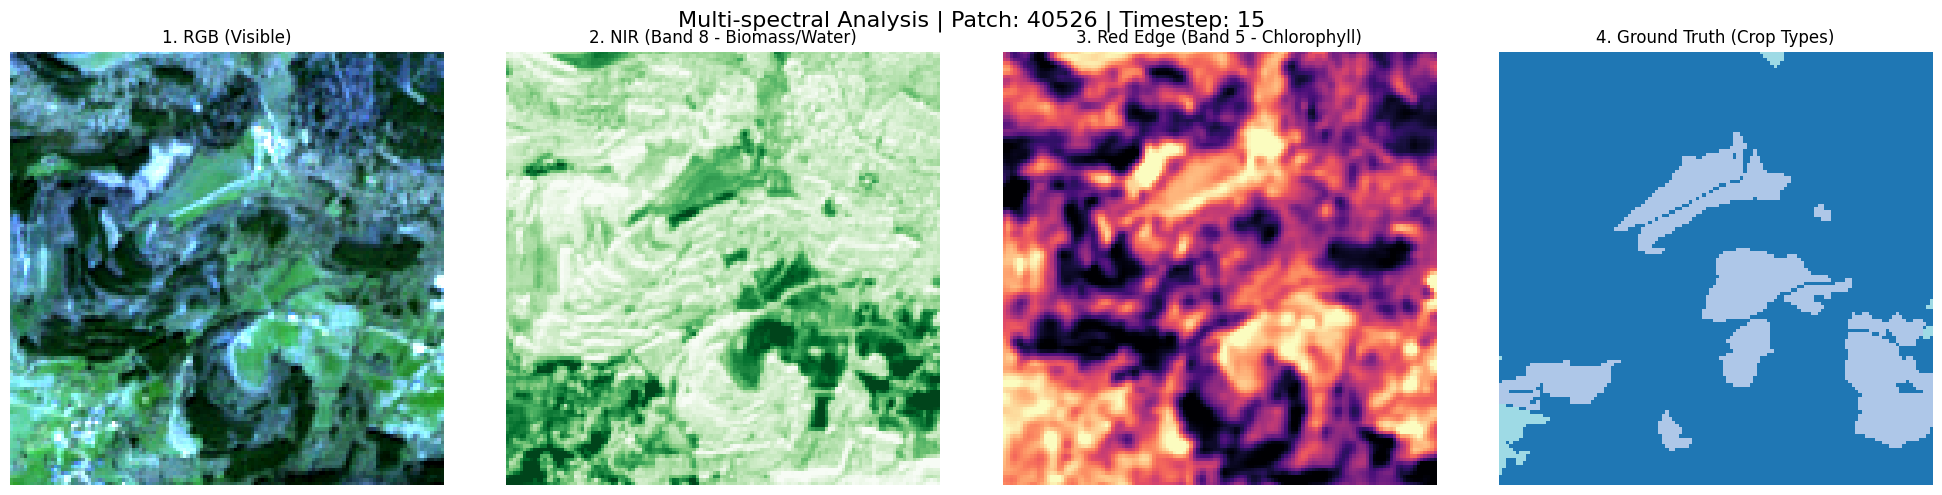

In [3]:
PATCH_ID = '40526'
DATA_PATH = f'/kaggle/input/datasets/khlaifiabilel/pastis/PASTIS/DATA_S2/S2_{PATCH_ID}.npy'
MASK_PATH = f'/kaggle/input/datasets/khlaifiabilel/pastis/PASTIS/ANNOTATIONS/TARGET_{PATCH_ID}.npy'

def pastis_visualizer(data_path, mask_path, time_idx=15):
    data = np.load(data_path)
    mask = np.load(mask_path)
    
    semantic_mask = mask[0]
    
    print("-" * 50)
    print("ЭНТОМОЛОГИЯ ТЕНЗОРА (Анализ структуры):")
    print(f"Файл данных: {os.path.basename(data_path)}")
    print(f"Shape данных: {data.shape} -> (Время: {data.shape[0]}, Каналы: {data.shape[1]}, Размер: {data.shape[2]}x{data.shape[3]})")
    print(f"Shape маски:  {semantic_mask.shape} -> (Уникальных классов на снимке: {np.unique(semantic_mask)})")
    print("-" * 50)
    
    rgb = data[time_idx, :3, :, :].transpose(1, 2, 0)
    nir = data[time_idx, 6, :, :]
    red_edge = data[time_idx, 3, :, :]
    
    def normalize_img(img):
        p2, p98 = np.percentile(img, (2, 98))
        return np.clip((img - p2) / (p98 - p2 + 1e-8), 0, 1)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"Multi-spectral Analysis | Patch: {PATCH_ID} | Timestep: {time_idx}", fontsize=16)

    axes[0].imshow(normalize_img(rgb))
    axes[0].set_title("1. RGB (Visible)")
    axes[0].axis('off')

    axes[1].imshow(normalize_img(nir), cmap='Greens')
    axes[1].set_title("2. NIR (Band 8 - Biomass/Water)")
    axes[1].axis('off')

    axes[2].imshow(normalize_img(red_edge), cmap='magma')
    axes[2].set_title("3. Red Edge (Band 5 - Chlorophyll)")
    axes[2].axis('off')

    im_mask = axes[3].imshow(semantic_mask, cmap='tab20', interpolation='nearest')
    axes[3].set_title("4. Ground Truth (Crop Types)")
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

pastis_visualizer(DATA_PATH, MASK_PATH, time_idx=15)

In [4]:
class PASTISDataset(Dataset):
    def __init__(self, data_dir, annotations_dir, target_days=38):
        self.data_dir = data_dir
        self.annotations_dir = annotations_dir
        self.target_days = target_days
        self.patch_ids = []
        for filename in os.listdir(annotations_dir):
            if filename.startswith('TARGET_') and filename.endswith('.npy'):
                patch_id = filename.split('_')[1].split('.')[0]
                self.patch_ids.append(patch_id)
                
        print(f"инициализирован pastis_dataset. найдено патчей: {len(self.patch_ids)}")

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, idx):
        patch_id = self.patch_ids[idx]

        # мутим пути к снимку и его маске
        data_path = os.path.join(self.data_dir, f'S2_{patch_id}.npy')
        target_path = os.path.join(self.annotations_dir, f'TARGET_{patch_id}.npy')

        # загружаем снимок
        x_data = np.load(data_path) 
        
        # загружаем маску и только ее первый слой semantic segmentation
        y_data = np.load(target_path)[0] 

        # исправляем даты, так как в батчах они разные мазафака
        if x_data.shape[0] > self.target_days:
            x_data = x_data[:self.target_days]
        elif x_data.shape[0] < self.target_days:
            pad = np.zeros((self.target_days - x_data.shape[0], *x_data.shape[1:]))
            x_data = np.concatenate([x_data, pad], axis=0)

        # превращаем снимки в pytorch тензоры и превращаем их в float так как весы дробные
        x_tensor = torch.from_numpy(x_data).float()
        
        # функция потерь CrossEntropyLoss требует именно long формат, поэтому кастим маски в него
        y_tensor = torch.from_numpy(y_data).long() 

        return x_tensor, y_tensor

DATA_DIR = f'/kaggle/input/datasets/khlaifiabilel/pastis/PASTIS/DATA_S2/'
ANNOTATIONS_DIR = f'/kaggle/input/datasets/khlaifiabilel/pastis/PASTIS/ANNOTATIONS/'

# инициация механизма получения снимка и его маски
dataset = PASTISDataset(data_dir=DATA_DIR, annotations_dir=ANNOTATIONS_DIR)

# автоматизируем процесс preprocessing
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=0)

# чекаем работает ли, эмулирую один прогон
for batch_idx, (inputs, targets) in enumerate(dataloader):
    print(f"\nбатч #{batch_idx}")
    print(f"inputs (X) shape: {inputs.shape} -> (batch, dates, channels, height, width)")
    print(f"targets (Y) shape: {targets.shape} -> (batch, height, width)")
    break

инициализирован pastis_dataset. найдено патчей: 2433

батч #0
inputs (X) shape: torch.Size([2, 38, 10, 128, 128]) -> (batch, dates, channels, height, width)
targets (Y) shape: torch.Size([2, 128, 128]) -> (batch, height, width)


In [5]:
!rm -rf /kaggle/working/utae-paps

!git clone https://github.com/VSainteuf/utae-paps.git
!pip install -q segmentation-models-pytorch

Cloning into 'utae-paps'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 97 (delta 34), reused 21 (delta 21), pack-reused 46 (from 1)
Receiving objects: 100% (97/97), 3.11 MiB | 39.38 MiB/s, done.
Resolving deltas: 100% (42/42), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.8 MB/s eta 0:00:00


In [6]:
!touch /kaggle/working/utae-paps/src/__init__.py
!touch /kaggle/working/utae-paps/src/backbones/__init__.py

repo_path = '/kaggle/working/utae-paps'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

try:
    from src.backbones.utae import UTAE
    print("Успех! U-TAE теперь официально в системе.")
except ImportError as e:
    print(f"Ошибка импорта: {e}")

Успех! U-TAE теперь официально в системе.


In [7]:
from src.backbones.utae import UTAE

model = UTAE(
    input_dim=10,                       # наши 10 спектральных каналов
    encoder_widths=[64, 64, 64, 128],   # стандарт из статьи
    decoder_widths=[32, 32, 64, 128],
    n_head=16,
    d_model=256,
    return_maps=False
)

# Перенос на GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"модель загружена на: {device}")
print(f"количество параметров: {sum(p.numel() for p in model.parameters()):,}")

модель загружена на: cuda
количество параметров: 1,087,260


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

# устанавливаю seed
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Seed установлен: {seed}")

set_seed(42)

# подготовливаем два важных инстурмента
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def get_accuracy(pred, target):
    with torch.no_grad():
        pred_labels = torch.argmax(pred, dim=1)
        correct = (pred_labels == target).float().sum()
        return (correct / target.numel()).item()

# обучение
epochs = 15


for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    epoch_acc = 0
    
    for batch_idx, (inputs, targets) in enumerate(dataloader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        positions = torch.arange(38).repeat(inputs.size(0), 1).to(device)
        
        optimizer.zero_grad()
        
        # шаг 1, прогноз
        outputs = model(inputs, batch_positions=positions) 
        
        # шаг 2, расчёт ошибок
        loss = criterion(outputs, targets)
        
        # шаг 3, устанавливаем и обновляем весы модели
        loss.backward()
        optimizer.step()

        # статы одного батча
        acc = get_accuracy(outputs, targets)
        epoch_loss += loss.item()
        epoch_acc += acc
        
        # прогресс после каждых 20 батчей
        if batch_idx % 20 == 0:
            print(f"Эпоха {epoch+1}/{epochs} | Батч {batch_idx:04d} | Loss: {loss.item():.4f} | Acc: {acc:.2%}")

    # итоги всей эпохи
    avg_loss = epoch_loss / len(dataloader)
    avg_acc = epoch_acc / len(dataloader)
    
    print("-" * 40)
    print(f"   ИТОГ ЭПОХИ {epoch+1}:")
    print(f"   Средний Loss: {avg_loss:.4f}")
    print(f"   Средняя Точность: {avg_acc:.2%}")
    print("-" * 40)

# сохраняем результат
save_path = 'utae_pastis_final_v1.pth'
torch.save(model.state_dict(), save_path)

print(f"тугади браза, веса модели сохранены в файл: {save_path}")

Seed установлен: 42
Эпоха 1/15 | Батч 0000 | Loss: 3.2004 | Acc: 4.92%
Эпоха 1/15 | Батч 0020 | Loss: 2.8984 | Acc: 23.16%
Эпоха 1/15 | Батч 0040 | Loss: 2.6968 | Acc: 36.58%
Эпоха 1/15 | Батч 0060 | Loss: 2.6029 | Acc: 30.84%
Эпоха 1/15 | Батч 0080 | Loss: 2.3158 | Acc: 53.30%
Эпоха 1/15 | Батч 0100 | Loss: 2.4499 | Acc: 40.53%
Эпоха 1/15 | Батч 0120 | Loss: 2.7170 | Acc: 36.02%
Эпоха 1/15 | Батч 0140 | Loss: 2.3813 | Acc: 42.17%
Эпоха 1/15 | Батч 0160 | Loss: 2.2708 | Acc: 46.41%
Эпоха 1/15 | Батч 0180 | Loss: 2.0305 | Acc: 57.54%
Эпоха 1/15 | Батч 0200 | Loss: 2.0393 | Acc: 56.63%
Эпоха 1/15 | Батч 0220 | Loss: 2.3946 | Acc: 42.91%
Эпоха 1/15 | Батч 0240 | Loss: 1.9358 | Acc: 64.30%
Эпоха 1/15 | Батч 0260 | Loss: 1.9097 | Acc: 66.42%
Эпоха 1/15 | Батч 0280 | Loss: 1.9456 | Acc: 55.22%
Эпоха 1/15 | Батч 0300 | Loss: 2.2449 | Acc: 48.92%
Эпоха 1/15 | Батч 0320 | Loss: 2.0671 | Acc: 58.96%
Эпоха 1/15 | Батч 0340 | Loss: 1.8082 | Acc: 63.16%
Эпоха 1/15 | Батч 0360 | Loss: 2.5565 | Acc: 